# Package

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import  accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import warnings
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import joblib
import seaborn as sns
import math

warnings.filterwarnings("ignore")

#pip install xgboost==1.7.6

# Data Understanding & Preparation

In [5]:
df = pd.read_csv('train.csv')
df.head()

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,def_date,fs_year,asst_intang_fixed,asst_tang_fixed,...,inc_extraord,taxes,profit,days_rec,ebitda,roa,roe,wc_net,margin_fin,cf_operations
0,17,520288,2011-12-31,28.0,SRL,14.0,NaT,2011,67537.0,1137566.0,...,-309.0,-80959.0,-81288.0,NaN,6318.0,-3.81,-28.03,496258.0,-917029.0,-849.0
1,18,520288,2008-12-31,28.0,SRL,14.0,NaT,2008,256438.0,1181416.0,...,-678.0,-94622.0,-107382.0,NaN,46088.0,-2.76,NaN,97952.0,NaN,-3881.0
2,19,520288,2009-12-31,28.0,SRL,14.0,NaT,2009,194046.0,1152014.0,...,4224.0,-74235.0,-77819.0,NaN,67611.0,-2.17,NaN,-210671.0,NaN,32618.0
3,21,520288,2012-12-31,28.0,SRL,14.0,NaT,2012,15195.0,1116938.0,...,3634.0,-250786.0,-250786.0,NaN,-161478.0,-12.99,NaN,367892.0,-1094962.0,-168907.0
4,22,520288,2007-12-31,28.0,SRL,14.0,NaT,2007,126603.0,1127807.0,...,820.0,92192.0,36733.0,NaN,153060.0,6.20,52.43,-317007.0,-1184970.0,80039.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1023552 entries, 0 to 1023551
Data columns (total 44 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Unnamed: 0            1023552 non-null  int64  
 1   id                    1023552 non-null  int64  
 2   stmt_date             1023552 non-null  object 
 3   HQ_city               1023275 non-null  float64
 4   legal_struct          1023552 non-null  object 
 5   ateco_sector          1023552 non-null  float64
 6   def_date              1023552 non-null  object 
 7   fs_year               1023552 non-null  int64  
 8   asst_intang_fixed     1023390 non-null  float64
 9   asst_tang_fixed       1023449 non-null  float64
 10  asst_fixed_fin        1023315 non-null  float64
 11  asst_current          1023551 non-null  float64
 12  AR                    1023540 non-null  float64
 13  cash_and_equiv        1023535 non-null  float64
 14  asst_tot              1023552 non-

In [7]:
# Datetime Conversion
df['stmt_date'] = pd.to_datetime(df['stmt_date'])
df['def_date'] = pd.to_datetime(df['def_date'])


In [8]:
# check wehther all statement date are on 12/31
all((df['stmt_date'].dt.month == 12) & (df['stmt_date'].dt.day == 31))

True

## Target Variable

In [9]:
# define the target variable 'default'
df['firm_year_end'] = df['stmt_date'] + pd.DateOffset(years=1)+ pd.DateOffset(months=3)

df['default'] = df.apply(lambda x: 1 if pd.notna(x['def_date']) and 
                            (x['stmt_date'] <= x['def_date'] < x['firm_year_end']) else 0, axis=1)

In [10]:
default_counts = df['default'].value_counts()
# Number of default and nondefault
print(f"Number of rows with default=1: {default_counts.get(1, 0)}")
print(f"Number of rows with default=0: {default_counts.get(0, 0)}")

Number of rows with default=1: 14114
Number of rows with default=0: 1009438


## Independent Variables

In [11]:
variables = ['eqty_tot', 'asst_tot', 'liab_lt', 'liab_lt_emp', 'roa', 'rev_operating', 'COGS',
            'cf_operations', 'AP_lt', 'debt_lt', 'debt_fin_lt', 'debt_bank_lt', 'asst_current']
print(df[variables].isna().sum()) 

eqty_tot             1
asst_tot             0
liab_lt            294
liab_lt_emp        162
roa                 27
rev_operating      174
COGS                24
cf_operations       88
AP_lt            92244
debt_lt            155
debt_fin_lt      92068
debt_bank_lt     90971
asst_current         1
dtype: int64


In [12]:
(df[variables] == 0).sum()

eqty_tot             15
asst_tot              0
liab_lt          641396
liab_lt_emp      331579
roa                2277
rev_operating     31217
COGS                647
cf_operations      1073
AP_lt            910254
debt_lt          281542
debt_fin_lt      851880
debt_bank_lt     451100
asst_current        170
dtype: int64

In [13]:
df[variables].describe()

,eqty_tot,asst_tot,liab_lt,liab_lt_emp,roa,rev_operating,COGS,cf_operations,AP_lt,debt_lt,debt_fin_lt,debt_bank_lt,asst_current
count,1.023551e+06,1.023552e+06,1.023258e+06,1.023390e+06,1.023525e+06,1.023378e+06,1.023528e+06,1.023464e+06,9.313080e+05,1.023397e+06,9.314840e+05,9.325810e+05,1.023551e+06
mean,3.585192e+06,1.111351e+07,3.385748e+05,2.328660e+05,2.914601e+00,8.645592e+06,8.355932e+06,4.041489e+05,2.293656e+04,1.982039e+06,1.174775e+05,1.133471e+06,5.957970e+06
std,8.996885e+07,1.799274e+08,4.606932e+07,5.459489e+06,1.023380e+01,1.404518e+08,1.391105e+08,1.202904e+07,1.297701e+06,2.653971e+07,4.398384e+06,1.337126e+07,5.419817e+07
min,-8.052920e+08,1.500000e+06,-1.283245e+06,-3.373560e+05,-9.639000e+02,-1.117299e+08,-5.049269e+07,-1.914280e+09,-5.879780e+05,-9.602000e+06,-5.449856e+06,-2.301536e+06,0.000000e+00
25%,1.673525e+05,2.170073e+06,0.000000e+00,0.000000e+00,1.100000e-01,4.330672e+05,3.812672e+05,4.902000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.072830e+06
50%,7.189230e+05,3.458428e+06,0.000000e+00,3.491800e+04,2.390000e+00,1.983749e+06,1.886857e+06,7.604500e+04,0.000000e+00,3.653850e+05,0.000000e+00,2.578400e+04,2.040524e+06
75%,2.059212e+06,6.975953e+06,2.082000e+04,1.671930e+05,5.200000e+00,4.953758e+06,4.752647e+06,2.393900e+05,0.000000e+00,1.424715e+06,0.000000e+00,7.289840e+05,4.135408e+06
max,3.356488e+10,7.164463e+10,2.707827e+10,1.734028e+09,9.075600e+02,4.320688e+10,4.326022e+10,3.377050e+09,7.332880e+08,8.838206e+09,2.229168e+09,3.199651e+09,1.479057e+10


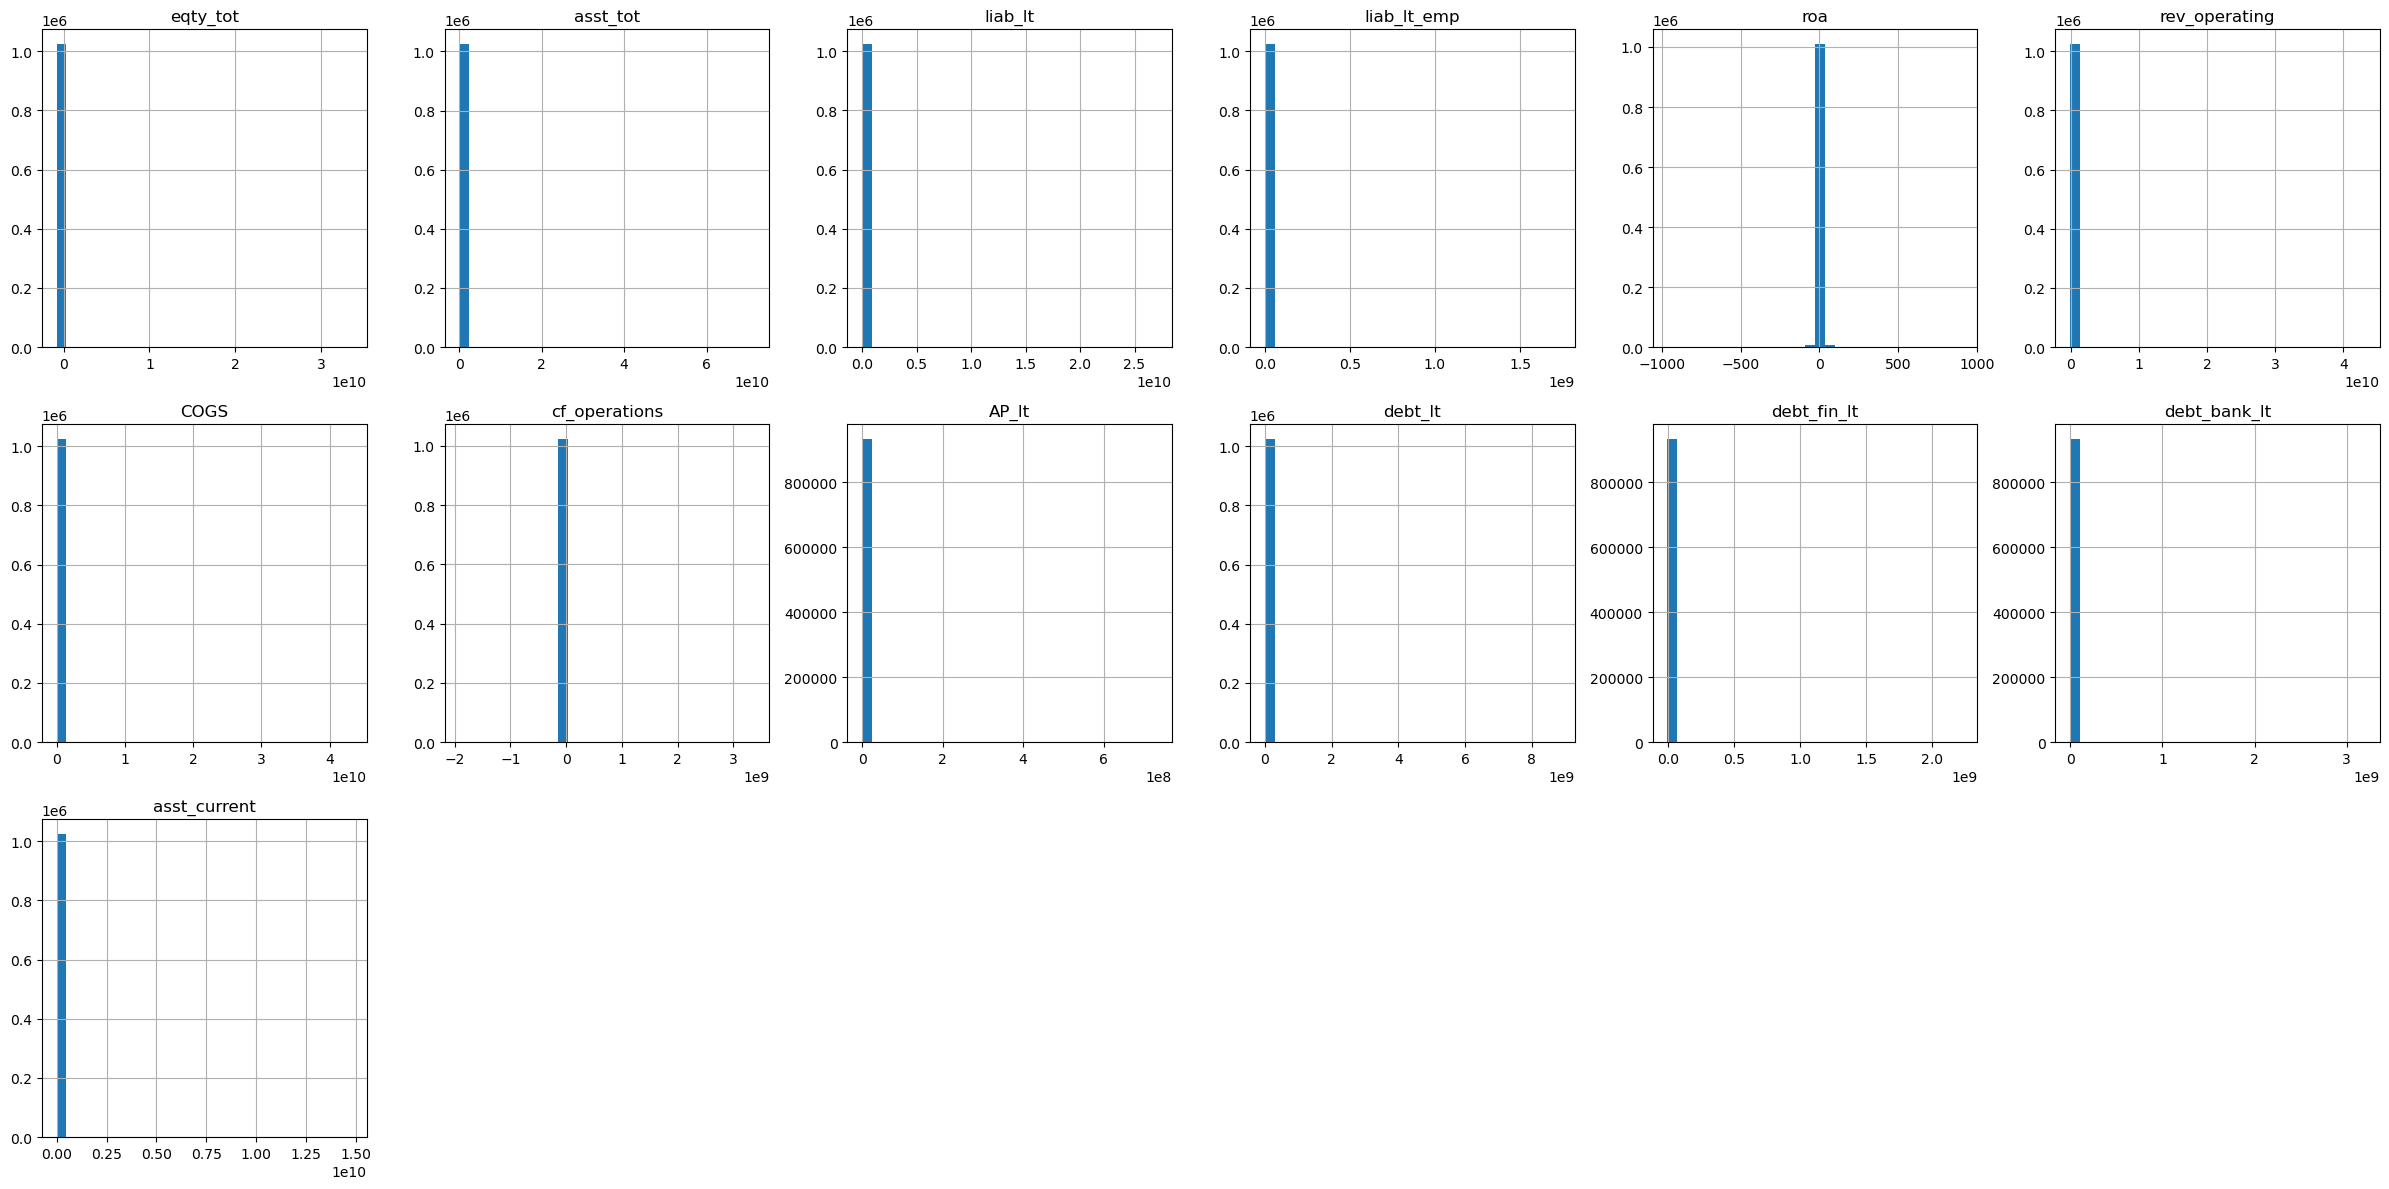

In [14]:
# Visualize the variable distributions
num_cols = len(df[variables].columns)
n_rows = math.ceil(num_cols / 6)  # 6 plot in each row

fig, axes = plt.subplots(n_rows, 6, figsize=(24, 4 * n_rows))  
axes = axes.flatten() 

for i, col in enumerate(df[variables].columns):
    ax = axes[i]  
    if df[col].dtype in ['int64', 'float64']:  # Numerical columns
        df[col].hist(bins=30, ax=ax)
        ax.set_title(col)
    else:  # Categorical columns
        sns.countplot(x=col, data=df, ax=ax)
        ax.set_title(col)

# remove blank plots
for i in range(len(df[variables].columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


## Imputing missing values with K-mean clustering

In [15]:
# temporarily fill missing value with column medians
imputer = SimpleImputer(strategy='median')
df_temp = pd.DataFrame(imputer.fit_transform(df[variables]), columns=variables, index=df.index)

# scale the data for clustering
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_temp)

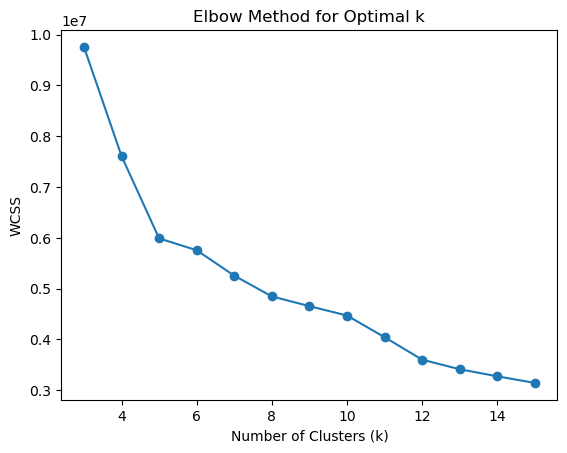

In [16]:
# Elbow method to find optimal number of clusters
wcss = []
for k in range(3, 16):
    kmeans = KMeans(n_clusters=k, random_state=24)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(3, 16), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

In [17]:
# clustering with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=24)
clusters = kmeans.fit_predict(df_scaled)
df['Cluster'] = clusters

# calculate cluster medians
cluster_medians = df.groupby('Cluster')[variables].median()

# replacing missing value with cluster medians
for cluster in df['Cluster'].unique():
    for variable in variables:
        mask = (df['Cluster'] == cluster) & (df[variable].isna())
        df.loc[mask, variable] = cluster_medians.loc[cluster, variable]


# check current missing values
print("Missing values after imputation:\n", df[variables].isna().sum())


Missing values after imputation:
 eqty_tot         0
asst_tot         0
liab_lt          0
liab_lt_emp      0
roa              0
rev_operating    0
COGS             0
cf_operations    0
AP_lt            0
debt_lt          0
debt_fin_lt      0
debt_bank_lt     0
asst_current     0
dtype: int64


## Feature Engineering

In [18]:
# calculate total liabilities
df['total_liabilities'] = df['asst_tot'] - df['eqty_tot']


# calculate current liabilities
df['current_liabilities'] = df['total_liabilities'] - df['liab_lt']- df['liab_lt_emp'] 
- df['AP_lt'] - df['debt_lt'] - df['debt_fin_lt'] - df['debt_bank_lt']


## Derived features
# Solvency
df['equity_ratio'] = df['total_liabilities'] / df['eqty_tot']


# Profitability: ROA (Return on Assets) / gross_profit_margin
df['roa'] = df['roa']

df['gross_profit_margin'] = np.where((df['COGS'] == 0) & (df['rev_operating'] == 0), 
    0,(df['rev_operating'] - df['COGS']) / df['rev_operating']) 


# Liquidity: Cash Flow Ratio = Operating Cash Flow 
## Alternative: Current ratio
df['operating_cashflow_ratio'] = np.where((df['cf_operations'] == 0) & (df['current_liabilities'] == 0), 
    0, df['cf_operations'] / df['current_liabilities'])

#df['current_ratio'] = np.where((df['asst_current'] == 0) & (df['current_liabilities'] == 0), 
    #0, df['asst_current'] / df['current_liabilities'])



# Size: Total Assets
df['size'] = np.log(df['asst_tot'])


target = 'default'
features = ['equity_ratio', 'roa', 'size', 'operating_cashflow_ratio', 'gross_profit_margin']

In [19]:
df[features].head()

,equity_ratio,roa,size,operating_cashflow_ratio,gross_profit_margin
0,5.714003,-3.81,14.481769,-0.000538,-0.137751
1,-56.655620,-2.76,14.546602,-0.001893,-0.059348
2,-44.773101,-2.17,14.496521,0.016701,-0.067053
3,46.784916,-12.99,14.442989,-0.096802,-0.760990
4,24.251527,6.20,14.385994,0.048979,0.053771


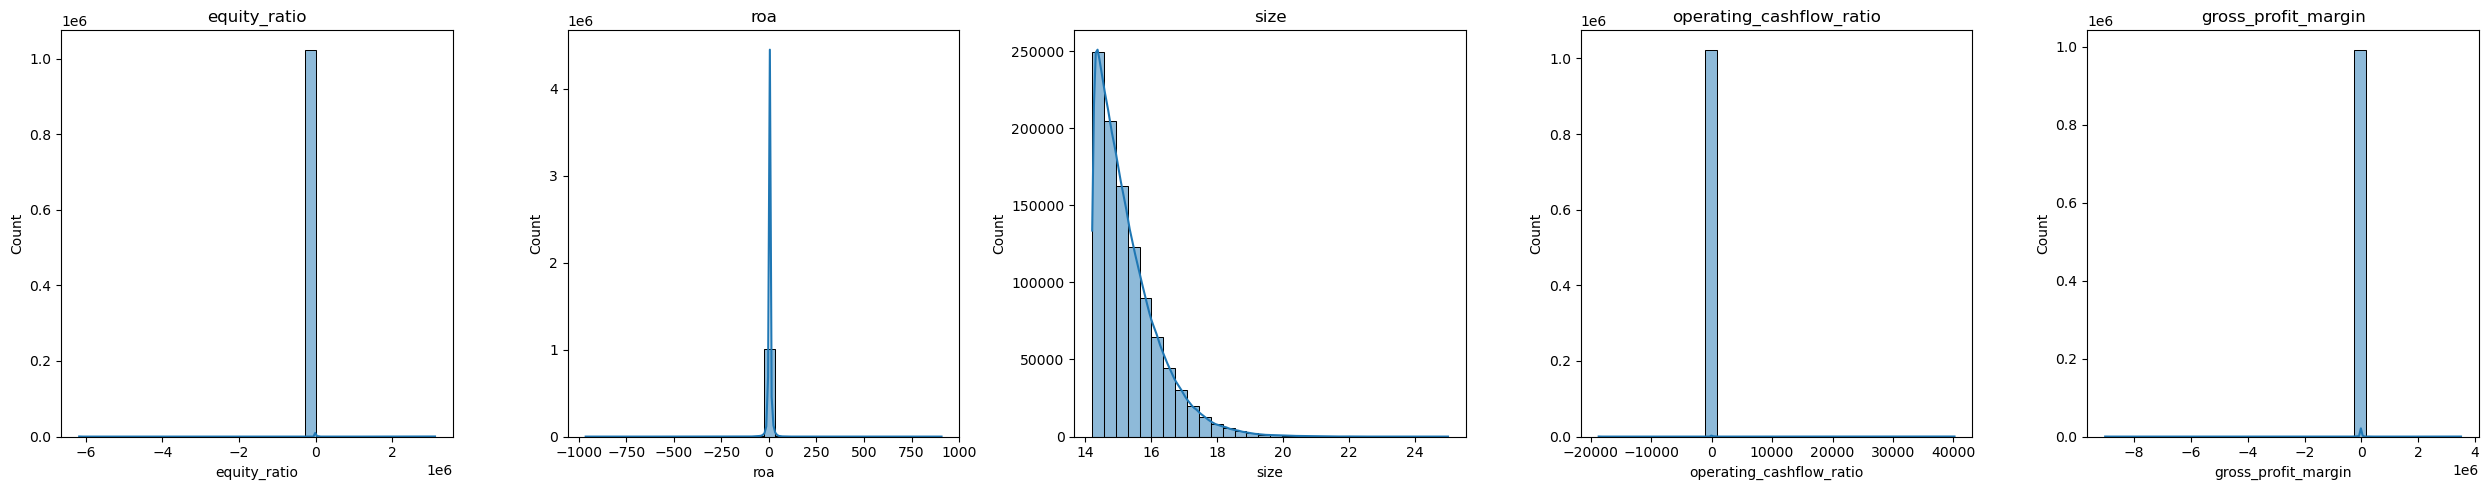

In [20]:
# visualize features distribution
fig, axes = plt.subplots(1, 5, figsize=(25, 5))  
axes = axes.flatten() 

for i, feature in enumerate(features):
    sns.histplot(df[feature], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(feature)

# remove blank plots
if len(features) < len(axes):
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout() 
plt.show()

In [21]:
print(df[features].isna().sum()) 

equity_ratio                0
roa                         0
size                        0
operating_cashflow_ratio    0
gross_profit_margin         0
dtype: int64


### Handling inf or -inf

In [22]:
for feature in features:
    # 1. replace inf or -inf with null values
    df[feature].replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # 2. replace null values with medians
    median_value = df[feature].median()
    df[feature].fillna(median_value, inplace=True)

In [23]:
print(df[features].isna().sum()) 

equity_ratio                0
roa                         0
size                        0
operating_cashflow_ratio    0
gross_profit_margin         0
dtype: int64


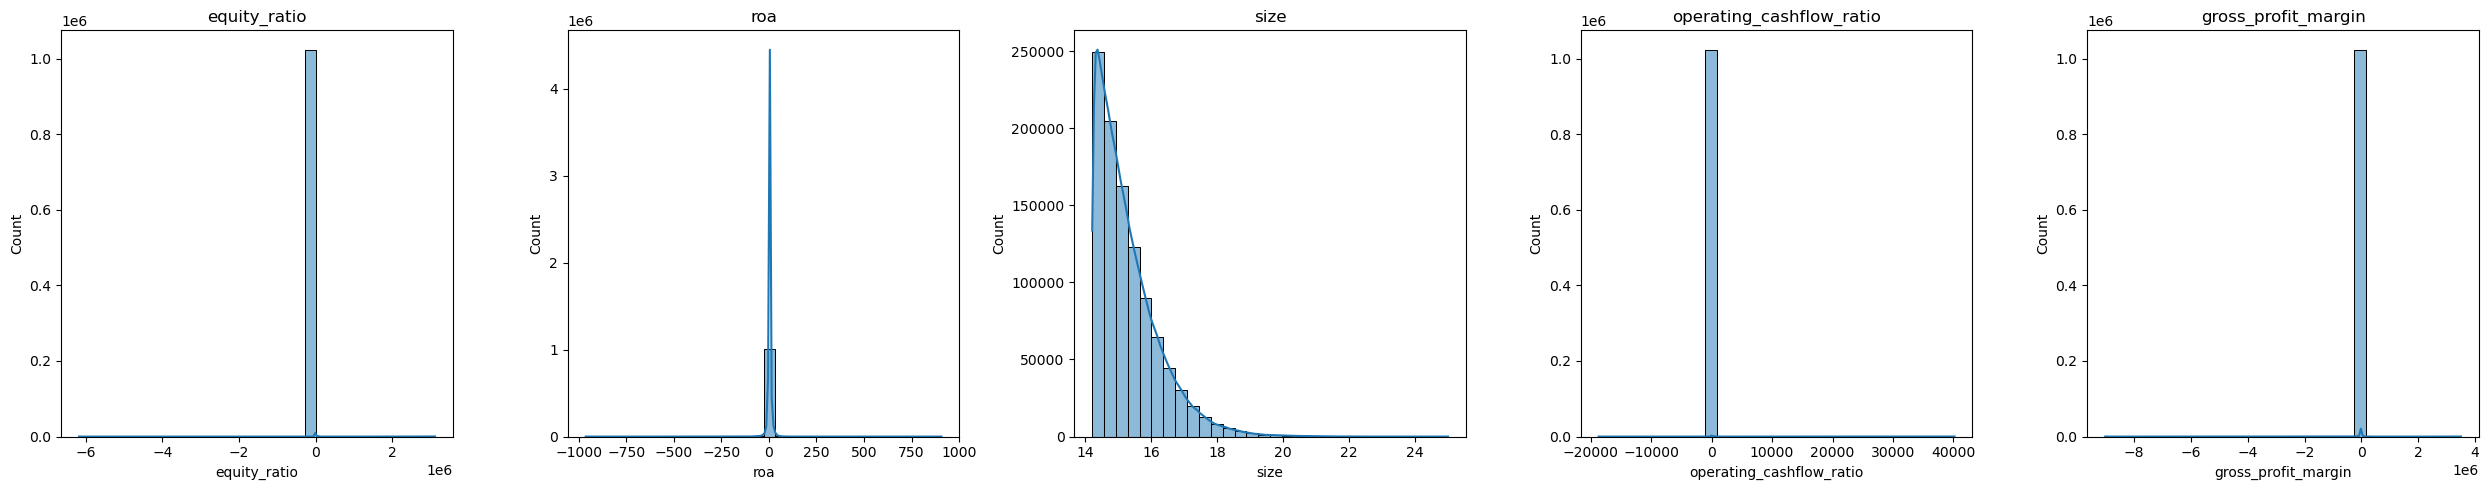

In [24]:
# visualize features distribution
fig, axes = plt.subplots(1, 5, figsize=(25, 5))  
axes = axes.flatten() 

for i, feature in enumerate(features):
    sns.histplot(df[feature], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(feature)

# remove blank plots
if len(features) < len(axes):
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout() 
plt.show()


# plot shows that distribution does not change much means the median imputation does not create outliers or bias

## Collinearity Check (VIF)

In [25]:
vif_data = pd.DataFrame()
vif_data['feature'] = df[features].columns
vif_data['VIF'] = [variance_inflation_factor(df[features], i) for i in range(df[features].shape[1])]

print(vif_data)

                    feature       VIF
0              equity_ratio  1.000006
1                       roa  1.080945
2                      size  1.080496
3  operating_cashflow_ratio  1.000046
4       gross_profit_margin  1.000773


# Models

In [26]:
# train test split
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## 1. Baseline - Decision Tree

In [27]:
# fit the tree model
model_dt = DecisionTreeClassifier(random_state=42, max_depth=5)
model_dt.fit(X_train, y_train)

# predict on test dataset with trained tree model
y_pred_dt = model_dt.predict(X_test)
y_pred_proba_dt = model_dt.predict_proba(X_test)[:, 1]


ROC-AUC Score: 0.81


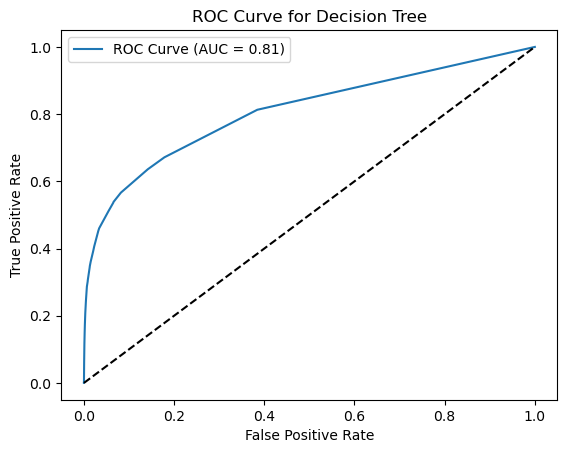

In [28]:
# check model power with ROC Curve and AUC Score
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
auc_score_dt = roc_auc_score(y_test, y_pred_proba_dt)

roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
print(f"\nROC-AUC Score: {roc_auc_dt:.2f}")

plt.plot(fpr_dt, tpr_dt, label=f'ROC Curve (AUC = {auc_score_dt:.2f})')
plt.plot([0, 1], [0, 1], 'k--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Decision Tree')
plt.legend()
plt.show()


Feature Importance:
                    Feature  Importance
0              equity_ratio    0.433798
1                       roa    0.420184
3  operating_cashflow_ratio    0.141145
4       gross_profit_margin    0.004325
2                      size    0.000549


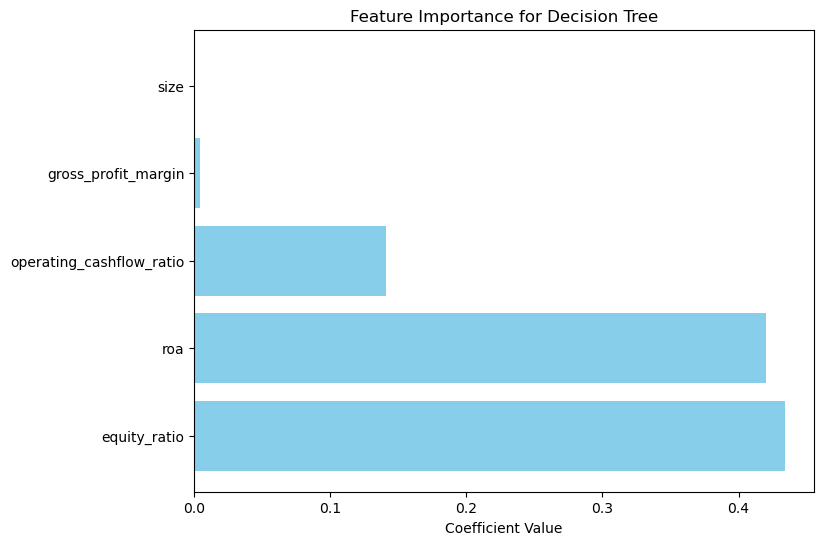

In [29]:
# check feature importance for decision tree
feature_importance_dt = pd.DataFrame({'Feature': X.columns, 'Importance': model_dt.feature_importances_})
print("\nFeature Importance:")
print(feature_importance_dt.sort_values(by='Importance', ascending=False))

plt.show()
plt.figure(figsize=(8, 6))
feature_importance_dt.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(feature_importance_dt['Feature'], feature_importance_dt['Importance'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance for Decision Tree')
plt.show()

## 2. XGBoost

In [30]:
# Grid Search for tuning XGBoost model
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

model_xgb = XGBClassifier()
grid_search = GridSearchCV(estimator=model_xgb, param_grid=param_grid, cv=3, scoring='roc_auc', verbose=1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC Score:", grid_search.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best ROC-AUC Score: 0.851979515853567


We used grid search to tune the XGBoost model and get the best parameter set.

In [31]:
# fit model with best parameters and make prediction on test set

best_params = grid_search.best_params_  
model_xgb = XGBClassifier(**best_params)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
y_pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]


ROC-AUC Score: 0.85


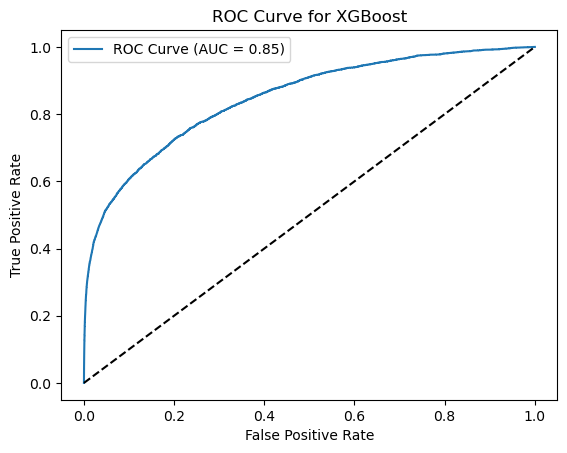

In [32]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
auc_score_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

roc_auc_xgb_updated = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"\nROC-AUC Score: {roc_auc_xgb_updated:.2f}")

plt.plot(fpr_xgb, tpr_xgb, label=f'ROC Curve (AUC = {auc_score_xgb:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend()
plt.show()

The ROC curve, with an AUC of 0.85, indicates good model performance in distinguishing between positive (default) and negative (non-default) classes. An AUC of 0.85 suggests that the model has a high probability of ranking a randomly chosen positive instance higher than a randomly chosen negative instance. This performance measure helps confirm that the selected features and the model’s structure provide a reliable classification of default risk. 
Compared with our baseline decision tree model, the AUC increased from 0.81 to 0.85.

### Feature Importance


Feature Importance:
                    Feature  Importance
3  operating_cashflow_ratio    0.330323
1                       roa    0.324786
0              equity_ratio    0.263903
4       gross_profit_margin    0.044621
2                      size    0.036366


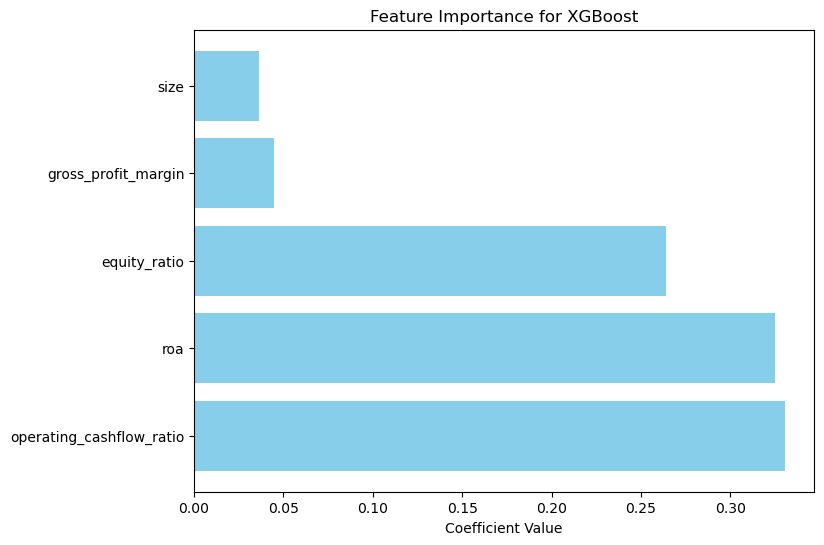

In [33]:
feature_importance_xgb = pd.DataFrame({'Feature': X.columns, 'Importance': model_xgb.feature_importances_})
print("\nFeature Importance:")
print(feature_importance_xgb.sort_values(by='Importance', ascending=False))


plt.show()
plt.figure(figsize=(8, 6))
feature_importance_xgb.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(feature_importance_xgb['Feature'], feature_importance_xgb['Importance'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance for XGBoost')
plt.show()

## XGBoost Calibration

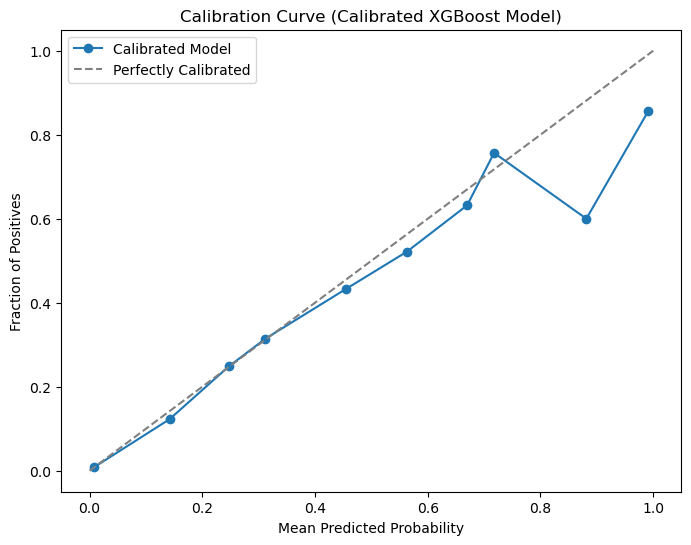

In [34]:
# 'isotonic' regression method is a non-parametric calibration technique work for non linear data
# 'prefit' means the model is calibrated after it is trained
calibrated_xgb = CalibratedClassifierCV(estimator=model_xgb, method='isotonic', cv='prefit')
calibrated_xgb.fit(X_train, y_train)

y_pred_calibrated = calibrated_xgb.predict(X_test)
y_pred_proba_calibrated = calibrated_xgb.predict_proba(X_test)[:, 1]

prob_true, prob_pred = calibration_curve(y_test, y_pred_proba_calibrated, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Calibrated XGBoost Model)')
plt.legend()
plt.show()

In [ ]:
model_xgb.get_booster().save_model("model_xgb.json")  # Save the trained model